# Vector compression — token study + search your class PDFs

**Survey:** JL projections, rank-k SVD, sign/scalar quantization — see `docs/SURVEY.md`.

**Part A:** 230 word embeddings (toy nearest-neighbor demo).

**Part B (main idea):** Index **MATH 5110 Canvas PDFs** → ask questions → retrieve lecture/homework passages (RAG retrieval). We also measure whether **compressing the index** still finds the right chunks.

**Part C:** Type your own question (e.g. "What is SVD?") and see top matching chunks.

Requires `.env` with `AZURE_OPENAI_*` and `CANVAS_*`. CLI: `uv run python scripts/search_class.py "your question"`

In [6]:
%matplotlib inline

import sys
from pathlib import Path

import polars as pl
from IPython.display import display, Markdown


def find_repo() -> Path:
    here = Path.cwd().resolve()
    for parent in [here, *here.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    raise RuntimeError("Open this notebook from the repo (e.g. python/notebooks/)")


REPO = find_repo()
sys.path.insert(0, str(REPO / "python" / "src"))

from vector_linalg.config import load_config
from vector_linalg.embeddings import embedding_matrix, fetch_token_embeddings
from vector_linalg.metrics import results_table
from vector_linalg.plots import (
    figure_distance_error,
    figure_rag_compare,
    figure_recall_vs_bits,
    figure_token_pca,
)
from vector_linalg.rag import fetch_rag_embeddings, run_rag_compression_study, search_corpus
from vector_linalg.study import run_compression_study

cfg = load_config()
provider = cfg.embeddings.provider
display(Markdown(f"Repo: `{cfg.repo_root}` | embeddings: **{provider}** | RAG source: **{cfg.rag.source}**"))

Repo: `C:\Users\tclay\Documents\Projects\math5110-portfolio-linalg` | embeddings: **azure** | RAG source: **canvas**

## Part A — Token embedding compression (toy universe)

In [7]:
df = fetch_token_embeddings(cfg)
tokens, keys = embedding_matrix(df)
dim = keys.shape[1]
display(Markdown(f"**{len(tokens)}** tokens, **d={dim}** (`{cfg.embeddings.model}` via {provider})"))
display(df.select(["token", "d0", "d1", "d2", "d3"]).head(8))

**230** tokens, **d=256** (`text-embedding-3-small` via azure)

token,d0,d1,d2,d3
str,f64,f64,f64,f64
"""the""",-0.002838,-0.007935,0.039856,0.057648
"""a""",0.054565,0.017731,-0.018585,0.054016
"""is""",-0.064453,0.025146,0.039673,0.040588
"""are""",-0.009514,-0.038116,0.05661,0.087891
"""was""",-0.051697,0.002161,-0.002151,0.012688
"""be""",0.078003,0.016693,0.018661,0.049835
"""have""",0.008621,0.007744,0.019958,0.026138
"""do""",0.008904,0.006596,-0.037537,0.09906


In [8]:
token_results = run_compression_study(keys, cfg)
display(results_table(token_results, cfg.recall_k))

method,bits_per_dim,compression_ratio,mean_distance_rel_error,recall_at_10
str,f64,f64,f64,f64
"""full_precision""",32.0,1.0,3.1093e-8,1.0
"""scalar_8bit""",8.0,4.0,0.000303,0.996667
"""scalar_4bit""",4.0,8.0,0.006876,0.958333
"""rank_64""",16.904348,1.893004,0.099781,0.883333
"""scalar_2bit""",2.0,16.0,0.143471,0.825
…,…,…,…,…
"""jl_128""",16.0,2.0,0.048817,0.591667
"""jl_64""",8.0,4.0,0.076002,0.5
"""rank_8""",2.113043,15.144033,0.537754,0.453333


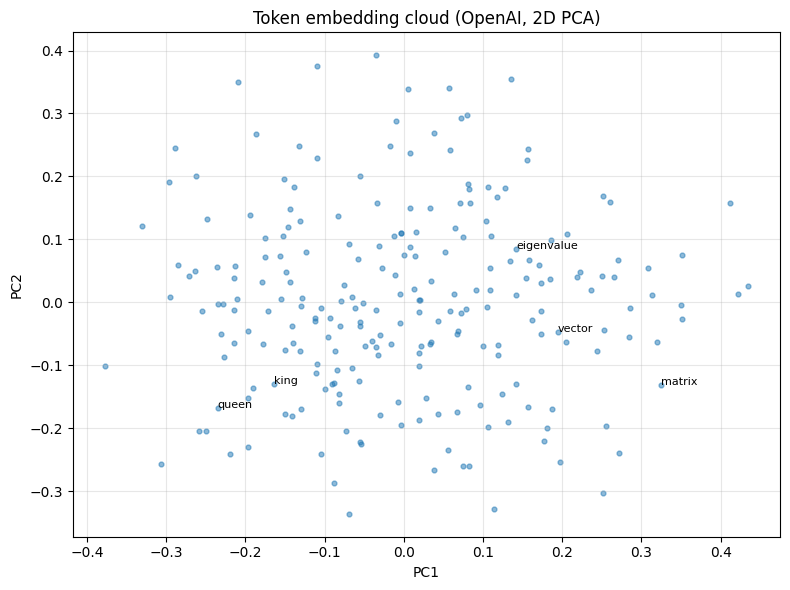

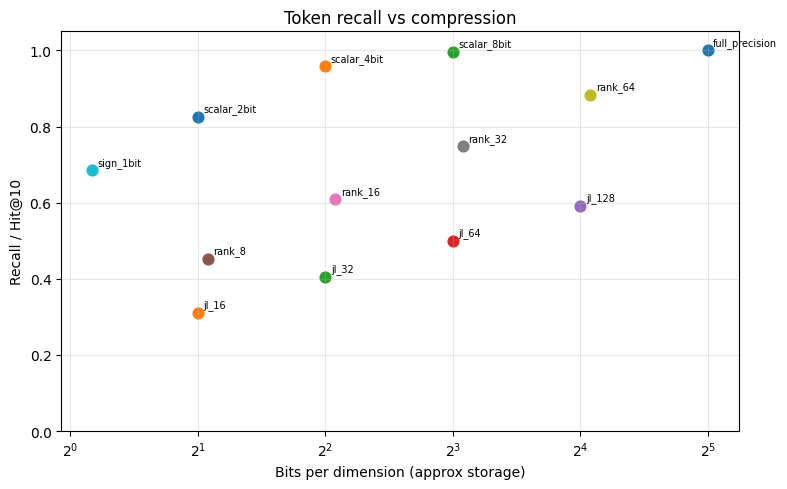

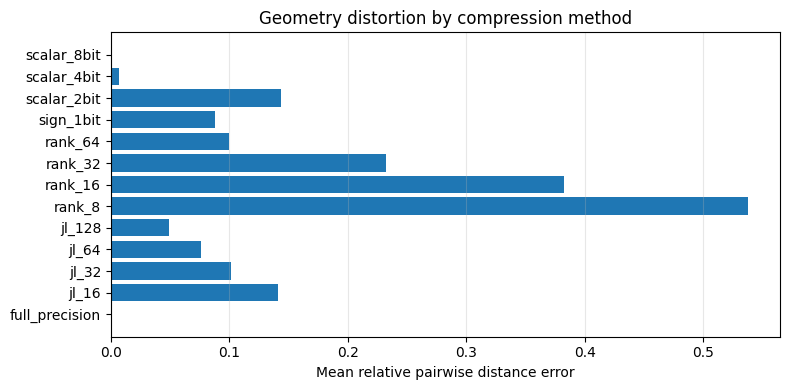

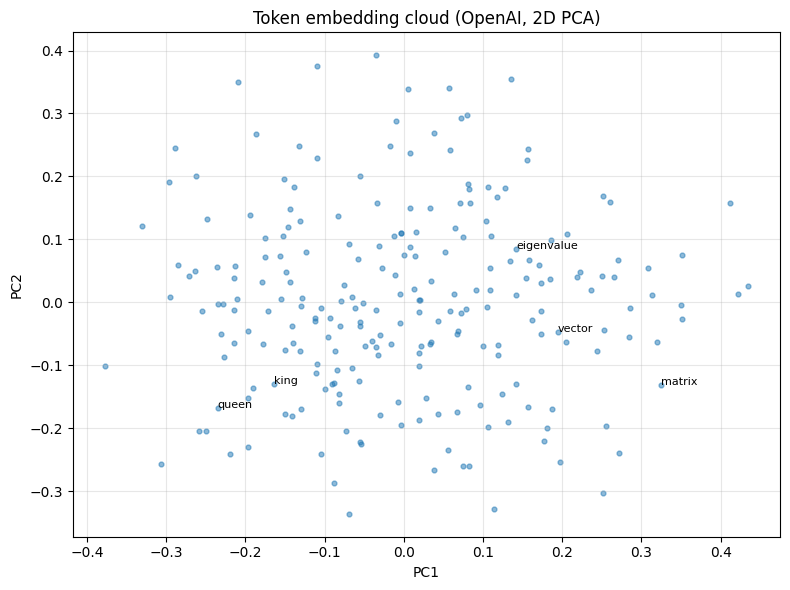

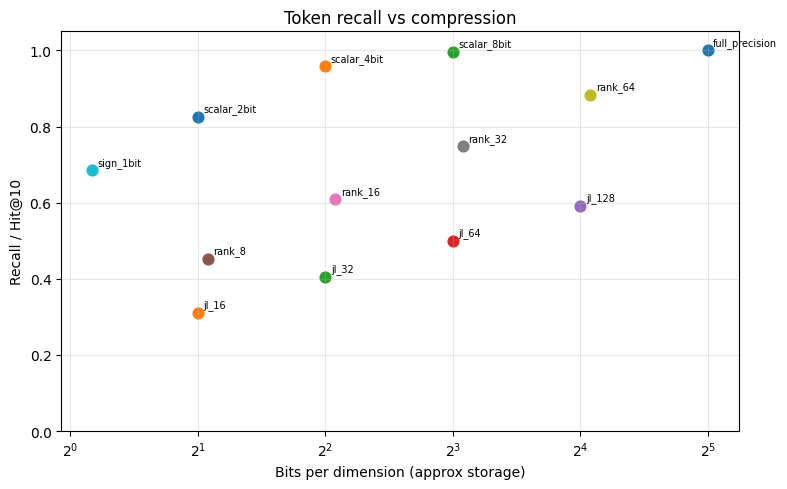

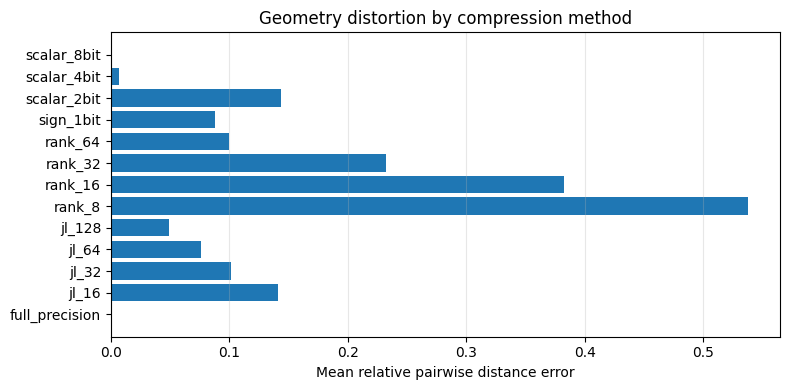

In [9]:
display(figure_token_pca(keys, tokens, highlight=["king", "queen", "matrix", "vector", "eigenvalue"]))
display(figure_recall_vs_bits(token_results, cfg.recall_k, title="Token recall vs compression"))
display(figure_distance_error(token_results))

## Part B — RAG on Canvas course PDFs

Pipeline (same as `scripts/run_all.py`):
1. Scrape linked `/files/<id>` URLs from Canvas module pages
2. Download PDFs → PyMuPDF text → ~900-char chunks
3. Embed all chunks (the **search index**)
4. Compress the index; score queries with hit@k

If `rag_queries.yaml` labels are stale, synthetic queries are built from sample chunk text.

In [10]:
if not cfg.rag.enabled:
    display(Markdown("RAG disabled in config.yaml"))
else:
    rag_bundle = fetch_rag_embeddings(cfg)
    n_chunks = len(rag_bundle.chunk_ids)
    n_queries = len(rag_bundle.query_texts)
    display(Markdown(f"**{n_chunks}** chunks from Canvas PDFs, **{n_queries}** eval queries"))

    sample = pl.DataFrame({
        "chunk_id": rag_bundle.chunk_ids[:5],
        "preview": [t[:120] + "..." for t in rag_bundle.chunk_texts[:5]],
    })
    display(sample)

Syncing content from Canvas...
  -> 1634 chunks from Canvas pages/PDFs
  Skipped 12 queries with stale chunk ids (label rag_queries.yaml later).
  Using synthetic hold-out queries (first 200 chars of sample chunks).


**1634** chunks from Canvas PDFs, **12** eval queries

chunk_id,preview
str,str
"""41510092_Lec2Draft_c000""","""Northeastern University, Depar…"
"""41510092_Lec2Draft_c001""","""⃗u =   u1 u2... un  an…"
"""41510092_Lec2Draft_c002""","""· · · + xn⃗an = ⃗b, which has …"
"""41510092_Lec2Draft_c003""","""be an m × n matrix, and let B …"
"""41510092_Lec2Draft_c004""","""X2, X3, X4, ... for the follow…"


method,bits_per_dim,compression_ratio,mean_distance_rel_error,recall_at_3
str,f64,f64,f64,f64
"""full_precision""",32.0,1.0,3.0328e-8,0.916667
"""jl_128""",16.0,2.0,0.051638,0.916667
"""rank_32""",4.626683,6.916402,0.236115,0.916667
"""rank_64""",9.253366,3.458201,0.133151,0.916667
"""sign_1bit""",1.125,28.444444,0.111512,0.916667
…,…,…,…,…
"""jl_64""",8.0,4.0,0.072316,0.833333
"""jl_32""",4.0,8.0,0.099237,0.75
"""rank_16""",2.313341,13.832804,0.350505,0.75


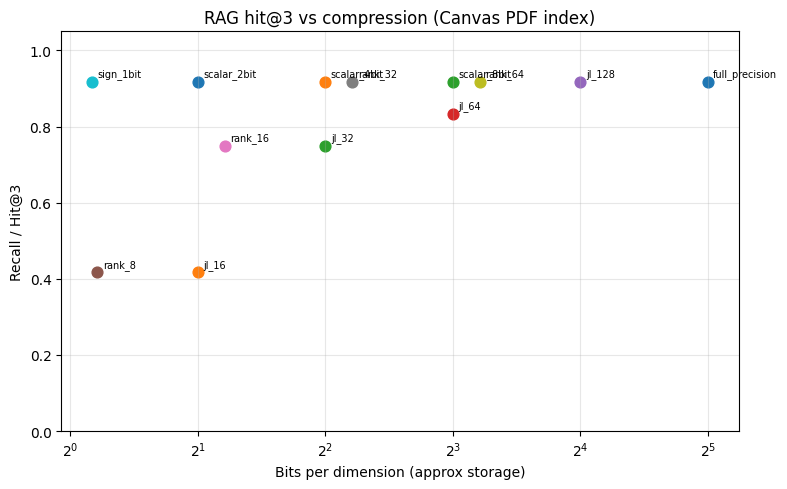

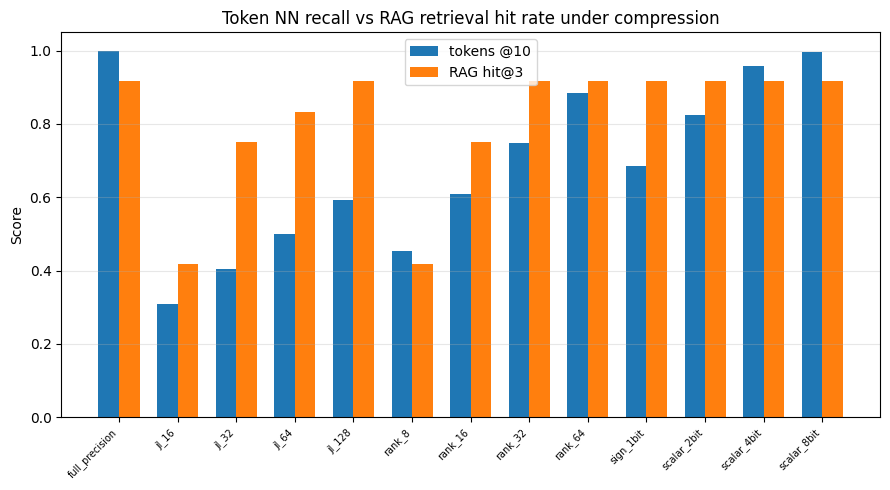

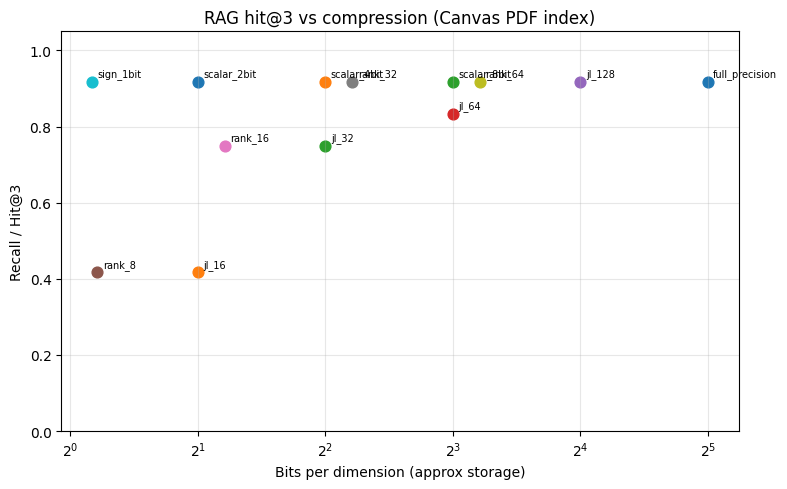

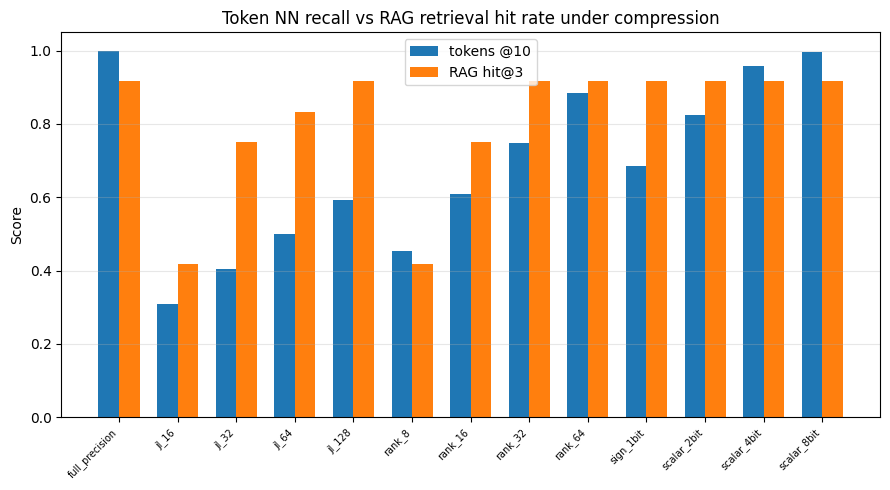

In [11]:
if cfg.rag.enabled:
    rag_results = run_rag_compression_study(rag_bundle, cfg)
    display(results_table(rag_results, cfg.rag.recall_k))

    display(figure_recall_vs_bits(
        rag_results,
        cfg.rag.recall_k,
        title=f"RAG hit@{cfg.rag.recall_k} vs compression (Canvas PDF index)",
    ))
    display(figure_rag_compare(
        token_results,
        rag_results,
        token_k=cfg.recall_k,
        rag_k=cfg.rag.recall_k,
    ))

## Search the class (interactive RAG)

Type a real question — the system embeds it and pulls the closest lecture/homework chunks from your Canvas PDF index. No LLM answer step; this is **retrieval only** (find the right passage to read or paste into a chatbot later).

In [ ]:
QUESTION = "What is the Perron-Frobenius theorem?"

if cfg.rag.enabled:
    for hit in search_corpus(QUESTION, rag_bundle, cfg, top_k=3):
        display(Markdown(f"**#{hit.rank}** (score {hit.score:.3f}) — `{hit.chunk_id}`"))
        display(Markdown(hit.text[:600] + ("..." if len(hit.text) > 600 else "")))